In [1]:
!pip install torch>=2.0.0 numpy>=1.24.0 matplotlib>=3.7.0 pygame>=2.5.0

###IMPORTS

In [2]:
import os
import csv
import torch
import random
import numpy as np
import torch.nn as nn
import torch.optim as optim
from collections import deque
import matplotlib.pyplot as plt

##Sanke Environment


In [3]:
UP    = (-1,  0)
DOWN  = ( 1,  0)
LEFT  = ( 0, -1)
RIGHT = ( 0,  1)

TURN_LEFT = {
    UP:    LEFT,
    LEFT:  DOWN,
    DOWN:  RIGHT,
    RIGHT: UP,
}
TURN_RIGHT = {
    UP:    RIGHT,
    RIGHT: DOWN,
    DOWN:  LEFT,
    LEFT:  UP,
}

class SnakeEnv:

    BASE_LOOP_LIMIT = 100

    def __init__(self, grid_size=10, obstacles=True):

        self.GRID_SIZE     = grid_size
        self.use_obstacles = obstacles
        a = grid_size // 3
        b = grid_size - a - 1
        self.obstacles = [(a, a), (a, a+1), (b, b), (b, b+1)] if obstacles else []

        self.reset()

    def reset(self):

        mid = self.GRID_SIZE // 2
        self.snake = [
            (mid, mid),
            (mid, mid - 1),
            (mid, mid - 2),
        ]
        self.direction        = RIGHT
        self.score            = 0
        self.steps            = 0
        self.steps_since_food = 0
        self.speed_level      = 1

        self._spawn_food()
        return self._get_state()

    def step(self, action):

        self.steps += 1
        self.steps_since_food += 1

        if action == 1:
            self.direction = TURN_LEFT[self.direction]
        elif action == 2:
            self.direction = TURN_RIGHT[self.direction]

        head_r, head_c = self.snake[0]
        dr, dc = self.direction
        new_head = (head_r + dr, head_c + dc)

        if self._is_collision(new_head):
            return self._get_state(), -10, True, self._info()

        self.snake.insert(0, new_head)

        if new_head == self.food:
            self.score            += 1
            self.steps_since_food  = 0
            reward                 = +10
            self._spawn_food()
            self.speed_level = 1 + (self.score // 3)

        else:
            self.snake.pop()
            reward = -0.1

        loop_limit = self.BASE_LOOP_LIMIT * (self.GRID_SIZE // 10)
        if self.steps_since_food > loop_limit:
            return self._get_state(), -10, True, self._info()

        return self._get_state(), reward, False, self._info()

    def _info(self):

        return {
            "score":        self.score,
            "speed_level":  self.speed_level,
            "snake_length": len(self.snake),
            "steps":        self.steps,
        }

    def _get_state(self):

        head = self.snake[0]
        head_r, head_c = head

        straight_pos = self._pos_in_direction(head, self.direction)
        left_pos      = self._pos_in_direction(head, TURN_LEFT[self.direction])
        right_pos     = self._pos_in_direction(head, TURN_RIGHT[self.direction])

        food_r, food_c = self.food

        state = [
            int(self._is_collision(straight_pos)),
            int(self._is_collision(left_pos)),
            int(self._is_collision(right_pos)),

            int(food_c < head_c),
            int(food_c > head_c),
            int(food_r < head_r),
            int(food_r > head_r),

            int(self.direction == LEFT),
            int(self.direction == RIGHT),
            int(self.direction == UP),
            int(self.direction == DOWN),
        ]

        return state

    def _is_collision(self, pos):

        r, c = pos

        if r < 0 or r >= self.GRID_SIZE or c < 0 or c >= self.GRID_SIZE:
            return True

        if pos in self.snake[1:]:
            return True

        if pos in self.obstacles:
            return True

        return False

    def _spawn_food(self):

        all_cells = [
            (r, c)
            for r in range(self.GRID_SIZE)
            for c in range(self.GRID_SIZE)
        ]
        occupied = set(self.snake) | set(self.obstacles)
        free_cells = [cell for cell in all_cells if cell not in occupied]

        if free_cells:
            self.food = random.choice(free_cells)
        else:
            self.food = None

    def _pos_in_direction(self, pos, direction):

        r, c = pos
        dr, dc = direction
        return (r + dr, c + dc)

##Q Network

In [4]:
class QNetwork(nn.Module):


    def __init__(
        self,
        input_size: int = 11,
        output_size: int = 3,
        use_deep: bool = False,
        dropout: float = 0.0,
    ) -> None:
        super().__init__()

        self.input_size = input_size
        self.output_size = output_size
        self.use_deep = use_deep
        self.dropout_prob = dropout

        if use_deep:
            self.network = self._build_deep_network(input_size, output_size, dropout)
        else:
            self.network = self._build_base_network(input_size, output_size, dropout)

    @staticmethod
    def _build_base_network(
        input_size: int, output_size: int, dropout: float
    ) -> nn.Sequential:

        layers = [
            nn.Linear(input_size, 256),
            nn.ReLU(),
        ]
        if dropout > 0.0:
            layers.append(nn.Dropout(p=dropout))

        layers += [
            nn.Linear(256, 128),
            nn.ReLU(),
        ]
        if dropout > 0.0:
            layers.append(nn.Dropout(p=dropout))

        layers.append(nn.Linear(128, output_size))

        return nn.Sequential(*layers)

    @staticmethod
    def _build_deep_network(
        input_size: int, output_size: int, dropout: float
    ) -> nn.Sequential:

        layers = [
            nn.Linear(input_size, 512),
            nn.ReLU(),
        ]
        if dropout > 0.0:
            layers.append(nn.Dropout(p=dropout))

        layers += [
            nn.Linear(512, 256),
            nn.ReLU(),
        ]
        if dropout > 0.0:
            layers.append(nn.Dropout(p=dropout))

        layers += [
            nn.Linear(256, 128),
            nn.ReLU(),
        ]
        if dropout > 0.0:
            layers.append(nn.Dropout(p=dropout))

        layers.append(nn.Linear(128, output_size))

        return nn.Sequential(*layers)



    def forward(self, x: torch.Tensor) -> torch.Tensor:

        x = self._prepare_input(x)
        return self.network(x)


    def predict(self, state) -> torch.Tensor:

        with torch.no_grad():
            tensor = self._to_tensor(state)
            q_values = self.network(tensor)
            return q_values.squeeze(0)



    def save(self, path: str) -> None:

        directory = os.path.dirname(path)
        if directory:
            os.makedirs(directory, exist_ok=True)

        torch.save(
            {
                "state_dict": self.state_dict(),
                "config": {
                    "input_size": self.input_size,
                    "output_size": self.output_size,
                    "use_deep": self.use_deep,
                    "dropout": self.dropout_prob,
                },
            },
            path,
        )

    def load(self, path: str) -> None:

        if not os.path.isfile(path):
            raise FileNotFoundError(f"Checkpoint not found: {path}")

        checkpoint = torch.load(path, map_location="cuda")
        self.load_state_dict(checkpoint["state_dict"])



    def _prepare_input(self, x: torch.Tensor) -> torch.Tensor:

        if not isinstance(x, torch.Tensor):
            x = torch.tensor(x, dtype=torch.float32)
        else:
            x = x.float()

        if x.dim() == 1:
            x = x.unsqueeze(0)

        return x

    @staticmethod
    def _to_tensor(state) -> torch.Tensor:

        if isinstance(state, torch.Tensor):
            tensor = state.float()
        else:
            tensor = torch.tensor(state, dtype=torch.float32)

        if tensor.dim() == 1:
            tensor = tensor.unsqueeze(0)

        return tensor



    def __repr__(self) -> str:
        mode = "deep" if self.use_deep else "base"
        return (
            f"QNetwork(input={self.input_size}, output={self.output_size}, "
            f"mode={mode}, dropout={self.dropout_prob})\n{self.network}"
        )



##Replay Buffer

In [5]:
class ReplayBuffer:

    def __init__(self, capacity=10000, batch_size=32, device="cpu"):
        self.memory = deque(maxlen=capacity)
        self.batch_size = batch_size
        self.device = device

    def push(self, state, action, reward, next_state, done):

        self.memory.append((state, action, reward, next_state, done))

    def sample(self):
        batch = random.sample(self.memory, self.batch_size)

        states, actions, rewards, next_states, dones = zip(*batch)

        # Convert to PyTorch tensors
        states      = torch.tensor(states, dtype=torch.float32).to(self.device)
        actions     = torch.tensor(actions, dtype=torch.long).to(self.device)
        rewards     = torch.tensor(rewards, dtype=torch.float32).to(self.device)
        next_states = torch.tensor(next_states, dtype=torch.float32).to(self.device)
        dones       = torch.tensor(dones, dtype=torch.float32).to(self.device)

        return states, actions, rewards, next_states, dones

    def __len__(self):
        return len(self.memory)

    def is_ready(self):
        return len(self.memory) >= self.batch_size

## RL Agent

In [6]:
class DQNAgent:
    def __init__(
        self,
        state_size,
        action_size,
        model_class,
        buffer,
        gamma=0.99,
        lr=0.001,
        batch_size=64,
        epsilon=1.0,
        epsilon_min=0.01,
        epsilon_decay=0.995,
        tau=0.005,
    ):
        self.state_size   = state_size
        self.action_size  = action_size
        self.memory       = buffer
        self.gamma        = gamma
        self.batch_size   = batch_size
        self.epsilon      = epsilon
        self.epsilon_min  = epsilon_min
        self.epsilon_decay= epsilon_decay
        self.tau          = tau
        self.device       = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.q_network      = model_class(state_size, action_size).to(self.device)
        self.target_network = model_class(state_size, action_size).to(self.device)
        self.target_network.load_state_dict(self.q_network.state_dict())
        self.target_network.eval()

        self.optimizer = optim.Adam(self.q_network.parameters(), lr=lr)
        self.criterion = nn.MSELoss()

    def select_action(self, state):
        if random.random() < self.epsilon:
            return random.randint(0, self.action_size - 1)
        state = torch.FloatTensor(state).unsqueeze(0).to(self.device)
        self.q_network.eval()
        with torch.no_grad():
            q_values = self.q_network(state)
        self.q_network.train()
        return torch.argmax(q_values).item()

    def store(self, state, action, reward, next_state, done):
        self.memory.push(state, action, reward, next_state, done)

    def learn(self):
        if not self.memory.is_ready():
            return None

        states, actions, rewards, next_states, dones = self.memory.sample()

        states      = states.to(self.device).float()
        actions     = actions.unsqueeze(1).to(self.device).long()
        rewards     = rewards.unsqueeze(1).to(self.device).float()
        next_states = next_states.to(self.device).float()
        dones       = dones.unsqueeze(1).to(self.device).float()

        with torch.no_grad():
            next_actions = torch.argmax(self.q_network(next_states), dim=1, keepdim=True)
            next_q       = self.target_network(next_states).gather(1, next_actions)
            target_q     = rewards + (1 - dones) * self.gamma * next_q

        current_q = self.q_network(states).gather(1, actions)
        loss      = self.criterion(current_q, target_q)

        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.q_network.parameters(), 1.0)
        self.optimizer.step()

        self.soft_update()
        return loss.item()

    def soft_update(self):
        for t_param, q_param in zip(self.target_network.parameters(), self.q_network.parameters()):
            t_param.data.copy_(self.tau * q_param.data + (1 - self.tau) * t_param.data)

    def decay_epsilon(self):
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay


#Training

###Hyperparameters

In [27]:
EPISODES       = 1000
STATE_SIZE     = 11
ACTION_SIZE    = 3
GAMMA          = 0.99
LR             = 0.0005  # 0.001
BATCH_SIZE     = 64
BUFFER_SIZE    = 10000
EPSILON        = 1.0
EPSILON_MIN    = 0.01
EPSILON_DECAY  = 0.5     # 0.995
TAU            = 0.001
TARGET_SCORE   = 15      # 20  # early stopping threshold
MOVING_AVG_N   = 50
SAVE_PATH      = "checkpoints/best_model.pth"
CSV_PATH       = "results/training_log.csv"

###Training Function

In [28]:
def train():
    os.makedirs("checkpoints", exist_ok=True)
    os.makedirs("results",      exist_ok=True)

    env    = SnakeEnv(grid_size=10, obstacles=True)
    buffer = ReplayBuffer(capacity=BUFFER_SIZE, batch_size=BATCH_SIZE,device='cuda')
    agent  = DQNAgent(
        state_size    = STATE_SIZE,
        action_size   = ACTION_SIZE,
        model_class   = QNetwork,
        buffer        = buffer,
        gamma         = GAMMA,
        lr            = LR,
        batch_size    = BATCH_SIZE,
        epsilon       = EPSILON,
        epsilon_min   = EPSILON_MIN,
        epsilon_decay = EPSILON_DECAY,
        tau           = TAU,
    )

    scores, losses, epsilons = [], [], []
    moving_avgs = []
    score_window = deque(maxlen=MOVING_AVG_N)
    best_avg = -float("inf")

    # ── CSV header ──
    with open(CSV_PATH, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["episode", "score", "avg_score", "loss", "epsilon"])

    for ep in range(1, EPISODES + 1):
        state = env.reset()
        total_reward = 0
        ep_losses    = []
        done         = False

        while not done:
            action = agent.select_action(state)
            next_state, reward, done, info = env.step(action)
            agent.store(state, action, reward, next_state, done)

            loss = agent.learn()
            if loss is not None:
                ep_losses.append(loss)

            state        = next_state
            total_reward += reward

        agent.decay_epsilon()

        score      = info["score"]
        avg_loss   = float(np.mean(ep_losses)) if ep_losses else 0.0
        scores.append(score)
        losses.append(avg_loss)
        epsilons.append(agent.epsilon)
        score_window.append(score)
        avg_score = float(np.mean(score_window))
        moving_avgs.append(avg_score)

        # ── Save best model ──
        if avg_score > best_avg and len(score_window) == MOVING_AVG_N:
            best_avg = avg_score
            agent.q_network.save(SAVE_PATH)

        # ── CSV row ──
        with open(CSV_PATH, "a", newline="") as f:
            writer = csv.writer(f)
            writer.writerow([ep, score, round(avg_score, 2), round(avg_loss, 4), round(agent.epsilon, 4)])

        # ── Console log ──
        if ep % 50 == 0:
            print(f"Ep {ep:4d} | Score {score:3d} | "
                  f"Avg(50) {avg_score:5.2f} | "
                  f"Loss {avg_loss:.4f} | ε {agent.epsilon:.3f}")

        # ── Early stopping ──
        if avg_score >= TARGET_SCORE and len(score_window) == MOVING_AVG_N:
            print(f"\n✅ Early stopping at episode {ep} — avg score {avg_score:.2f}")
            break

    plot_results(scores, moving_avgs, losses, epsilons)
    print(f"\nTraining complete. Best model saved to: {SAVE_PATH}")
    return agent, scores, moving_avgs, losses, epsilons



###Plot Function

In [29]:
def plot_results(scores, moving_avgs, losses, epsilons):
    os.makedirs("results", exist_ok=True)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("DQN Snake — Training Results", fontsize=16, fontweight="bold")

    axes[0, 0].plot(scores, alpha=0.4, color="steelblue", label="Score")
    axes[0, 0].set_title("Score per Episode")
    axes[0, 0].set_xlabel("Episode"); axes[0, 0].set_ylabel("Score")
    axes[0, 0].legend()

    axes[0, 1].plot(moving_avgs, color="darkorange", label=f"Moving Avg ({MOVING_AVG_N})")
    axes[0, 1].axhline(TARGET_SCORE, color="green", linestyle="--", label="Target")
    axes[0, 1].set_title("Moving Average Score")
    axes[0, 1].set_xlabel("Episode"); axes[0, 1].set_ylabel("Avg Score")
    axes[0, 1].legend()

    axes[1, 0].plot(epsilons, color="purple", label="Epsilon")
    axes[1, 0].set_title("Epsilon Decay")
    axes[1, 0].set_xlabel("Episode"); axes[1, 0].set_ylabel("Epsilon")
    axes[1, 0].legend()

    axes[1, 1].plot(losses, alpha=0.6, color="crimson", label="Loss")
    axes[1, 1].set_title("Training Loss")
    axes[1, 1].set_xlabel("Episode"); axes[1, 1].set_ylabel("MSE Loss")
    axes[1, 1].legend()

    plt.tight_layout()
    plt.savefig("results/training_curves.png", dpi=150)
    plt.show()
    print("Plots saved to results/training_curves.png")

###Start Training

Ep   50 | Score   9 | Avg(50)  2.54 | Loss 2.3245 | ε 0.008
Ep  100 | Score  19 | Avg(50) 14.46 | Loss 5.4226 | ε 0.008
Ep  150 | Score   4 | Avg(50) 14.14 | Loss 7.5064 | ε 0.008
Ep  200 | Score  17 | Avg(50) 13.86 | Loss 10.4797 | ε 0.008
Ep  250 | Score  19 | Avg(50) 12.76 | Loss 12.3636 | ε 0.008
Ep  300 | Score   7 | Avg(50) 13.56 | Loss 14.8010 | ε 0.008
Ep  350 | Score  18 | Avg(50) 15.04 | Loss 11.2187 | ε 0.008

✅ Early stopping at episode 350 — avg score 15.04


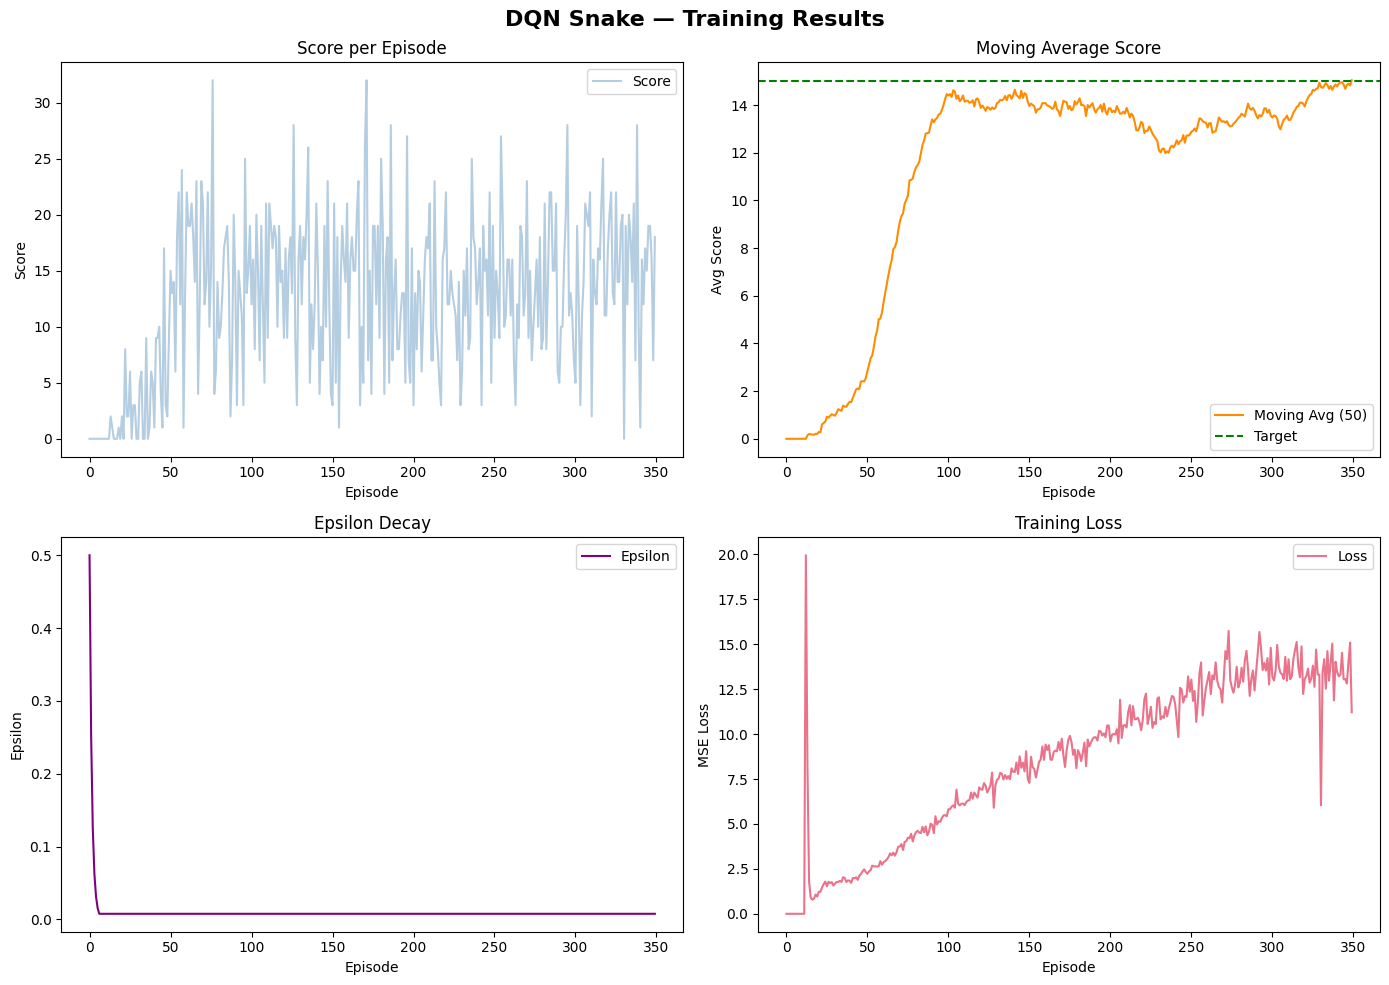

Plots saved to results/training_curves.png

Training complete. Best model saved to: checkpoints/best_model.pth


(<__main__.DQNAgent at 0x7b185072c200>,
 [0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  2,
  1,
  0,
  0,
  0,
  1,
  0,
  2,
  0,
  8,
  2,
  2,
  6,
  0,
  3,
  3,
  0,
  0,
  5,
  6,
  0,
  0,
  9,
  0,
  1,
  6,
  5,
  1,
  9,
  9,
  10,
  4,
  1,
  17,
  3,
  2,
  9,
  15,
  13,
  14,
  6,
  18,
  22,
  12,
  24,
  1,
  13,
  22,
  19,
  19,
  21,
  18,
  14,
  23,
  4,
  12,
  23,
  21,
  12,
  14,
  22,
  10,
  15,
  32,
  4,
  6,
  14,
  9,
  10,
  13,
  17,
  18,
  19,
  14,
  2,
  7,
  20,
  14,
  3,
  15,
  13,
  11,
  3,
  25,
  13,
  15,
  19,
  12,
  16,
  8,
  20,
  15,
  7,
  19,
  12,
  5,
  21,
  9,
  21,
  19,
  17,
  19,
  18,
  10,
  19,
  14,
  15,
  9,
  17,
  9,
  16,
  18,
  13,
  28,
  9,
  3,
  16,
  19,
  12,
  18,
  16,
  20,
  26,
  5,
  12,
  8,
  12,
  21,
  15,
  4,
  10,
  7,
  19,
  10,
  23,
  12,
  4,
  3,
  21,
  5,
  18,
  1,
  14,
  19,
  16,
  14,
  21,
  9,
  16,
  18,
  15,
  15,
  20,
  23,
  3,
  10,
  5,
  26,
  32,
  7,


In [30]:
train()

#Evaluation

###Parameters

In [31]:
CHECKPOINT  = "checkpoints/best_model.pth"
EVAL_EPS    = 100
STATE_SIZE  = 11
ACTION_SIZE = 3

###Random Agent baselin

In [32]:
def run_random_agent(episodes=EVAL_EPS):
    env    = SnakeEnv(grid_size=10, obstacles=True)
    scores = []
    for _ in range(episodes):
        env.reset()
        done = False
        while not done:
            _, _, done, info = env.step(random.randint(0, 2))
        scores.append(info["score"])
    return scores

###DQN Agent evaluation

In [33]:
def run_dqn_agent(episodes=EVAL_EPS):
    env    = SnakeEnv(grid_size=10, obstacles=True)
    buffer = ReplayBuffer(capacity=1000, batch_size=64)
    agent  = DQNAgent(
        state_size  = STATE_SIZE,
        action_size = ACTION_SIZE,
        model_class = QNetwork,
        buffer      = buffer,
        epsilon     = 0.0,      # pure exploitation
        epsilon_min = 0.0,
    )
    if os.path.isfile(CHECKPOINT):
        agent.q_network.load(CHECKPOINT)
        print(f"✅ Loaded checkpoint: {CHECKPOINT}")
    else:
        print("⚠️  No checkpoint found — evaluating untrained agent")

    scores = []
    for _ in range(episodes):
        state = env.reset()
        done  = False
        while not done:
            action = agent.select_action(state)
            state, _, done, info = env.step(action)
        scores.append(info["score"])
    return scores


###Comparison plot

In [34]:
def plot_comparison(dqn_scores, random_scores):
    os.makedirs("results", exist_ok=True)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("DQN vs Random Agent — Evaluation", fontsize=15, fontweight="bold")

    # Score distribution
    axes[0].hist(dqn_scores,    bins=15, alpha=0.7, color="steelblue",  label="DQN")
    axes[0].hist(random_scores, bins=15, alpha=0.7, color="darkorange", label="Random")
    axes[0].axvline(np.mean(dqn_scores),    color="steelblue",  linestyle="--")
    axes[0].axvline(np.mean(random_scores), color="darkorange", linestyle="--")
    axes[0].set_title("Score Distribution")
    axes[0].set_xlabel("Score"); axes[0].set_ylabel("Frequency")
    axes[0].legend()

    # Episode-by-episode line
    axes[1].plot(dqn_scores,    alpha=0.7, color="steelblue",  label="DQN")
    axes[1].plot(random_scores, alpha=0.7, color="darkorange", label="Random")
    axes[1].set_title("Score per Episode")
    axes[1].set_xlabel("Episode"); axes[1].set_ylabel("Score")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig("results/dqn_vs_random.png", dpi=150)
    plt.show()
    print("Comparison plot saved to results/dqn_vs_random.png")


###Evaluate

In [35]:
def evaluate():
    print("=" * 50)
    print("  Evaluating Random Agent ...")
    random_scores = run_random_agent()
    print(f"  Random → Mean: {np.mean(random_scores):.2f} | "
          f"Max: {max(random_scores)} | Std: {np.std(random_scores):.2f}")

    print("\n  Evaluating DQN Agent ...")
    dqn_scores = run_dqn_agent()
    print(f"  DQN    → Mean: {np.mean(dqn_scores):.2f} | "
          f"Max: {max(dqn_scores)} | Std: {np.std(dqn_scores):.2f}")

    improvement = np.mean(dqn_scores) - np.mean(random_scores)
    print(f"\n  Improvement over Random: {improvement:+.2f} points")
    print("=" * 50)

    plot_comparison(dqn_scores, random_scores)
    return dqn_scores, random_scores


###Start Evaluating

  Evaluating Random Agent ...
  Random → Mean: 0.05 | Max: 1 | Std: 0.22

  Evaluating DQN Agent ...
✅ Loaded checkpoint: checkpoints/best_model.pth
  DQN    → Mean: 16.44 | Max: 34 | Std: 6.39

  Improvement over Random: +16.39 points


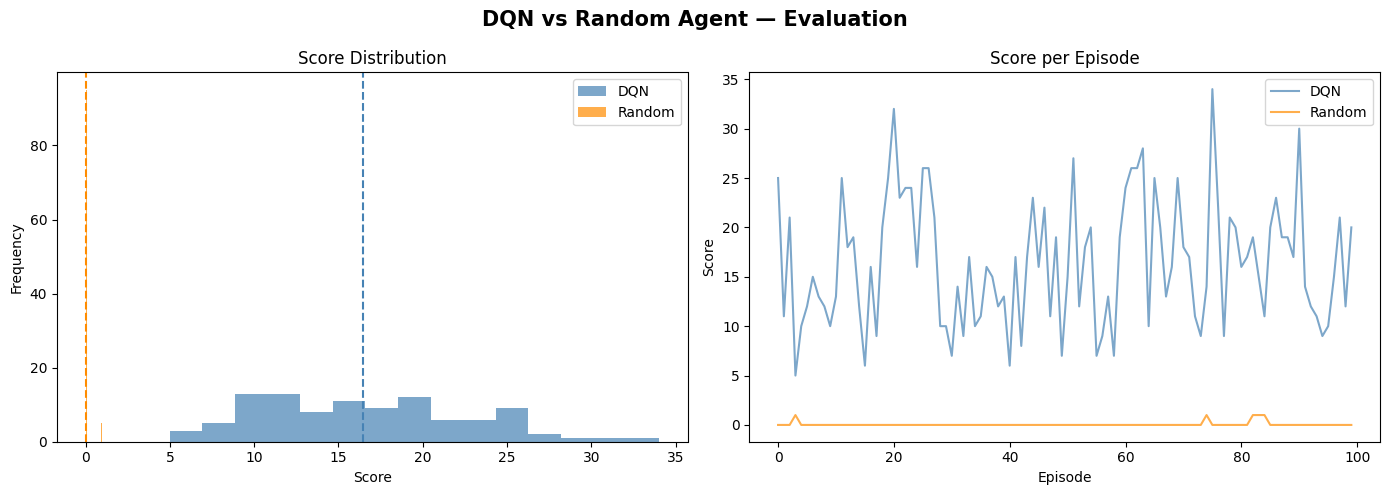

Comparison plot saved to results/dqn_vs_random.png


([25,
  11,
  21,
  5,
  10,
  12,
  15,
  13,
  12,
  10,
  13,
  25,
  18,
  19,
  12,
  6,
  16,
  9,
  20,
  25,
  32,
  23,
  24,
  24,
  16,
  26,
  26,
  21,
  10,
  10,
  7,
  14,
  9,
  17,
  10,
  11,
  16,
  15,
  12,
  13,
  6,
  17,
  8,
  17,
  23,
  16,
  22,
  11,
  19,
  7,
  15,
  27,
  12,
  18,
  20,
  7,
  9,
  13,
  7,
  19,
  24,
  26,
  26,
  28,
  10,
  25,
  20,
  13,
  16,
  25,
  18,
  17,
  11,
  9,
  14,
  34,
  22,
  9,
  21,
  20,
  16,
  17,
  19,
  15,
  11,
  20,
  23,
  19,
  19,
  17,
  30,
  14,
  12,
  11,
  9,
  10,
  15,
  21,
  12,
  20],
 [0,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1

In [36]:
evaluate()